In [ ]:
import pandas as pd
from transformers import BertTokenizer, BertModel
import torch
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load the pretrained tokenizer and model
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert").to(device)

In [3]:
def space_sequence(seq):
    return ' '.join(list(seq))

In [4]:
df = pd.read_csv("datasets/mutation_30mer_dataset153.csv")

sequences = df["Mut_30mer"].tolist()
labels = df["Label"].tolist()
df['spacedMut_30mer'] = df['Mut_30mer'].apply(space_sequence)

In [ ]:
#balanceing act
pathogenic_df = df[df['Label'] == 1]
benign_df = df[df['Label'] == 0]

min_count = min(len(pathogenic_df), len(benign_df))

pathogenic_balanced = resample(pathogenic_df, replace=False, n_samples=min_count, random_state=13)

benign_balanced = resample(benign_df, replace=False, n_samples=min_count, random_state=13)

df_balanced = pd.concat([pathogenic_balanced, benign_balanced])
df_balanced = df_balanced.sample(frac=1, random_state=13).reset_index(drop=True)

In [ ]:
def get_protbert_embedding(sequence):
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding

In [ ]:
if not os.path.exists('protbert_embeddings.csv'):
    embeddings = []
    for seq in df_balanced['spacedMut_30mer']:
        emb = get_protbert_embedding(seq)
        embeddings.append(emb.to('cpu').numpy())

    labels = df_balanced['Label'].values

    final_df = pd.DataFrame(embeddings)
    final_df['Label'] = labels

    final_df.to_csv('protbert_embeddings.csv', index=False)
else:
    final_df = pd.read_csv('protbert_embeddings.csv')

In [ ]:
X = final_df.drop(columns=["Label"]).values
y = final_df["Label"].values

clf = LogisticRegression(max_iter=700)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, stratify=y)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

Evaluation Metrics:
 {'Accuracy': 0.6590330788804071, 'Precision': 0.6567164179104478, 'Recall': 0.6700507614213198, 'F1 Score': 0.6633165829145728}


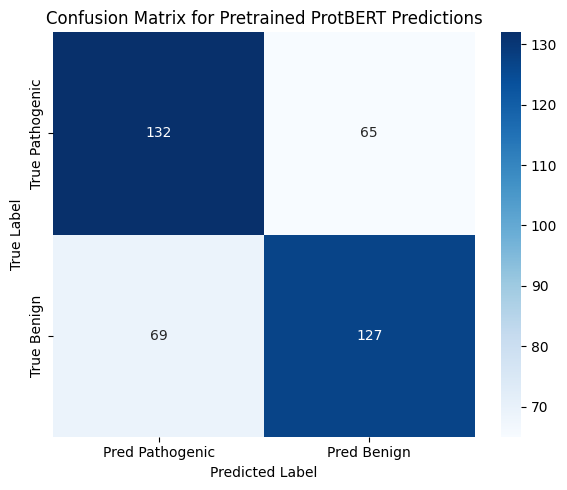

In [14]:
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1 Score': f1_score(y_val, y_pred),
}
print("Evaluation Metrics:\n", metrics)

conf_matrix = confusion_matrix(y_val, y_pred, labels=[1, 0])
report = classification_report(y_val, y_pred, labels=[1, 0], target_names=["pathogenic", "benign"], output_dict=True)

conf_df = pd.DataFrame(conf_matrix, index=["True Pathogenic", "True Benign"],
                       columns=["Pred Pathogenic", "Pred Benign"])
plt.figure(figsize=(6, 5))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Pretrained ProtBERT Predictions")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_16232\1530439321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")


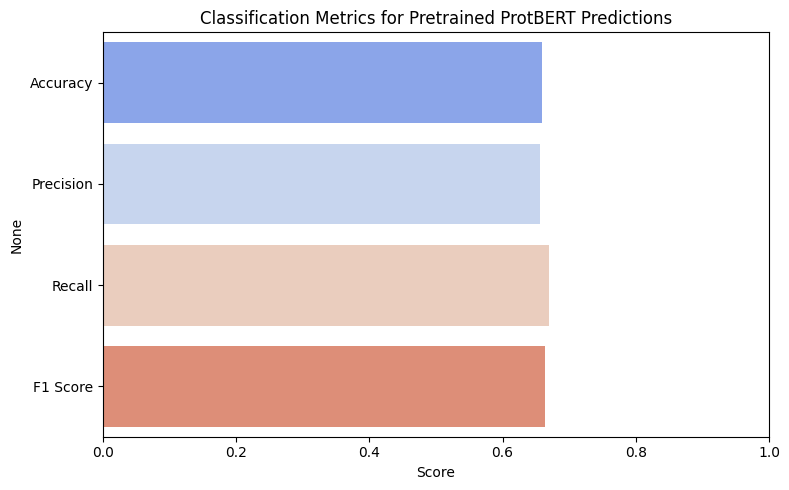

In [15]:
metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
plt.figure(figsize=(8, 5))
sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")
plt.title("Classification Metrics for Pretrained ProtBERT Predictions")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

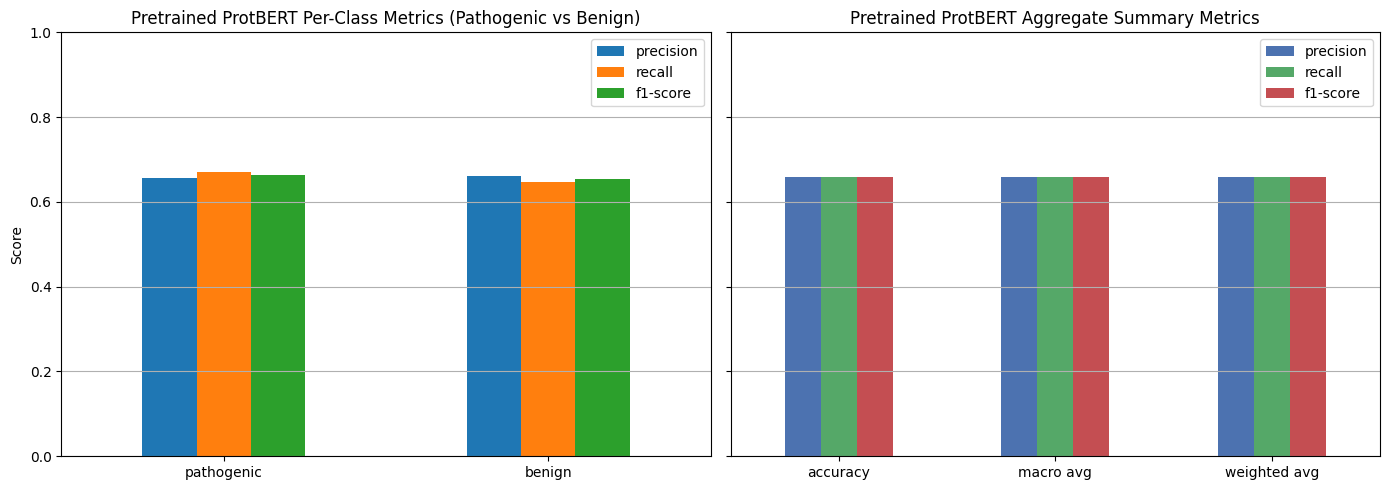

In [16]:
report_df = pd.DataFrame(report).transpose()

class_metrics = report_df.loc[['pathogenic', 'benign']]
summary_metrics = report_df.loc[['accuracy', 'macro avg', 'weighted avg']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

class_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[0])
axes[0].set_title("Pretrained ProtBERT Per-Class Metrics (Pathogenic vs Benign)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis='y')
axes[0].set_xticklabels(class_metrics.index, rotation=0)

summary_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[1], color=['#4c72b0', '#55a868', '#c44e52'])
axes[1].set_title("Pretrained ProtBERT Aggregate Summary Metrics")
axes[1].set_ylim(0, 1)
axes[1].grid(True, axis='y')
axes[1].set_xticklabels(summary_metrics.index, rotation=0)

plt.tight_layout()
plt.show()

In [17]:
print("\nFull Classification Report:")
print(pd.DataFrame(report).transpose())


Full Classification Report:
              precision    recall  f1-score     support
pathogenic     0.656716  0.670051  0.663317  197.000000
benign         0.661458  0.647959  0.654639  196.000000
accuracy       0.659033  0.659033  0.659033    0.659033
macro avg      0.659087  0.659005  0.658978  393.000000
weighted avg   0.659081  0.659033  0.658989  393.000000
